# 16 - Code Challenge: What does a model do with a class it never saw?

**Section:** FNNs | **Prereqs:** `FNNs/ShiftedMNIST.ipynb` | **Next:** `More on Data/Anatomy_of_DL_TD.ipynb`

Remove every 7 from the training set, train, then feed the model nothing but 7s.

**What happens.** It predicts confidently, and it is always wrong - usually 1, 9
or 2, whichever shares the most strokes. A softmax classifier is forced to
distribute probability over the classes it knows; 'none of these' is not an
option it has. High confidence is *not* evidence of correctness, and this is why
out-of-distribution detection is a separate problem from classification.

**The indexing trap** (see the note above the training cell): after dropping 7s,
the remaining labels are 0-6, 8, 9. The largest is still 9, so the output layer
must have 10 units even though logit 7 will never be trained. Sizing it to 9
gives the infamous `device-side assert triggered` from CUDA - the GPU version of
'index out of range'.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

In [26]:
# Colab ships a small MNIST CSV, so no download is needed. Column 0 is the
# label, columns 1-784 are the pixels.
data = pd.read_csv('/content/sample_data/mnist_train_small.csv')

In [27]:
# Split the CSV into labels and pixel matrix.
labels = (data.to_numpy())[:,0]
data = (data.to_numpy())[:,1:]

In [28]:
labels.shape

(19999,)

In [29]:
data.shape

(19999, 784)

In [30]:
# The experiment: a boolean mask selects every 7, then ~mask keeps everything
# else. The 7s become the test set - a test set made entirely of one unseen class.
# Removing all the 7s from the dataset


seven_loc = (labels == 7) # bool of the location if it has seven or not

data_no = data[~seven_loc,:]
label_no = labels[~seven_loc]

test_seven = data[seven_loc,:]

In [31]:
# Scale to [0,1], fitting on train and transforming test. Correct order.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_no = scaler.fit_transform(data_no)

test_seven = scaler.transform(test_seven)

In [43]:
# Tensors on GPU. Labels must be torch.long for CrossEntropyLoss.
# shuffle=True so batch composition changes every epoch - without it the model
# sees the same 32 samples together every time, which correlates the gradient
# noise instead of averaging it out.
data = torch.tensor(data_no,dtype=torch.float, device = "cuda")
label = torch.tensor(label_no, dtype=torch.long, device='cuda')

test_data = torch.tensor(test_seven, dtype=torch.float, device='cuda')



train_dataset = TensorDataset(data,label)

bs = 32
train_loader = DataLoader(train_dataset,batch_size=bs, drop_last=True, shuffle=True)

In [33]:
# Shapes after dropping ~6000 sevens.
data.shape, label_no.shape

(torch.Size([17873, 784]), (17873,))

In [34]:
# Confirms 7 is gone: the label set is 0-6, 8, 9.
np.unique(label.cpu()) # See there is no seven

array([0, 1, 2, 3, 4, 5, 6, 8, 9])

In [35]:
# Output layer has 10 units, not 9 - see the markdown note below for why.
# Logit 7 exists but nothing ever trains it, so it stays near its random init.
class classifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784,128)
    self.fc1 = nn.Linear(128,128)
    self.output_layer = nn.Linear(128,10) # dont put 9 check the comment below

  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    return self.output_layer(x)

### NOTE  • label indexing vs. output layer size
###- We dropped every sample whose label == 7, but we kept labels 0‐6, 8, 9.
###- The largest remaining label is 9, so CrossEntropyLoss expects 10 logits(indices 0‐9).  If the output layer has only 9 units (0‐8), any sample with label 9 is out of range and triggers:
###       RuntimeError: CUDA error: device‐side assert triggered
### Fixes:
###   1) Keep labels unchanged → make output_layer = nn.Linear(..., 10) (logit 7 is unused but harmless),  or
###   2) After loading data, do  labels[labels > 7] -= 1  so labels run 0‐8 then use output_layer = nn.Linear(..., 9)


In [38]:
# Standard training function. No test accuracy is tracked, because 'accuracy'
# is undefined here: every test label is a class the model cannot predict.
def train_model():

  model = classifier().to('cuda')

  lr = 1e-4
  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = lr)
  epochs = 50

  test_acc= []
  train_acc = []
  losses = []

  for epoch in range(epochs):

    model.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append( 100 * torch.mean( (torch.argmax(yhat,dim=1) == y).float() ).cpu() )


    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch {epoch} | Loss : {losses[epoch]}')


  return train_acc,losses, model

In [39]:
# Train it.
train_acc,losses, model = train_model()

Epoch 0 | Loss : 1.1680747241209057
Epoch 10 | Loss : 0.17255227163928064
Epoch 20 | Loss : 0.09658581542191647
Epoch 30 | Loss : 0.05473245981259532
Epoch 40 | Loss : 0.02900938078006696
Epoch 49 | Loss : 0.014541731172931418


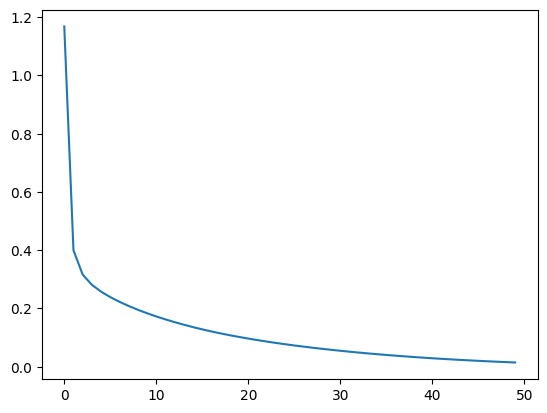

In [40]:
# Loss falls normally - from the model's point of view nothing is unusual.
plt.plot(losses);

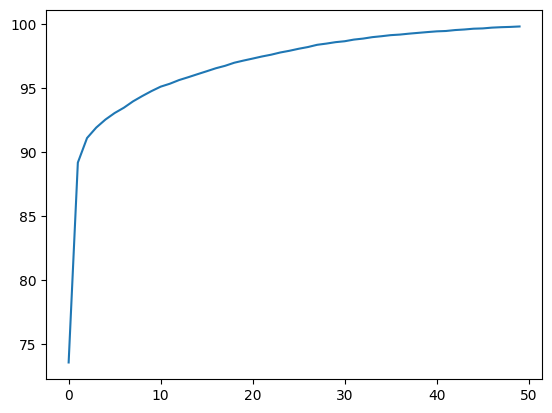

In [89]:
# Train accuracy reaches the usual level on the 9 classes it does know.
plt.plot(train_acc);

In [46]:
# Predict on the held-out 7s.
preds = model(test_data)


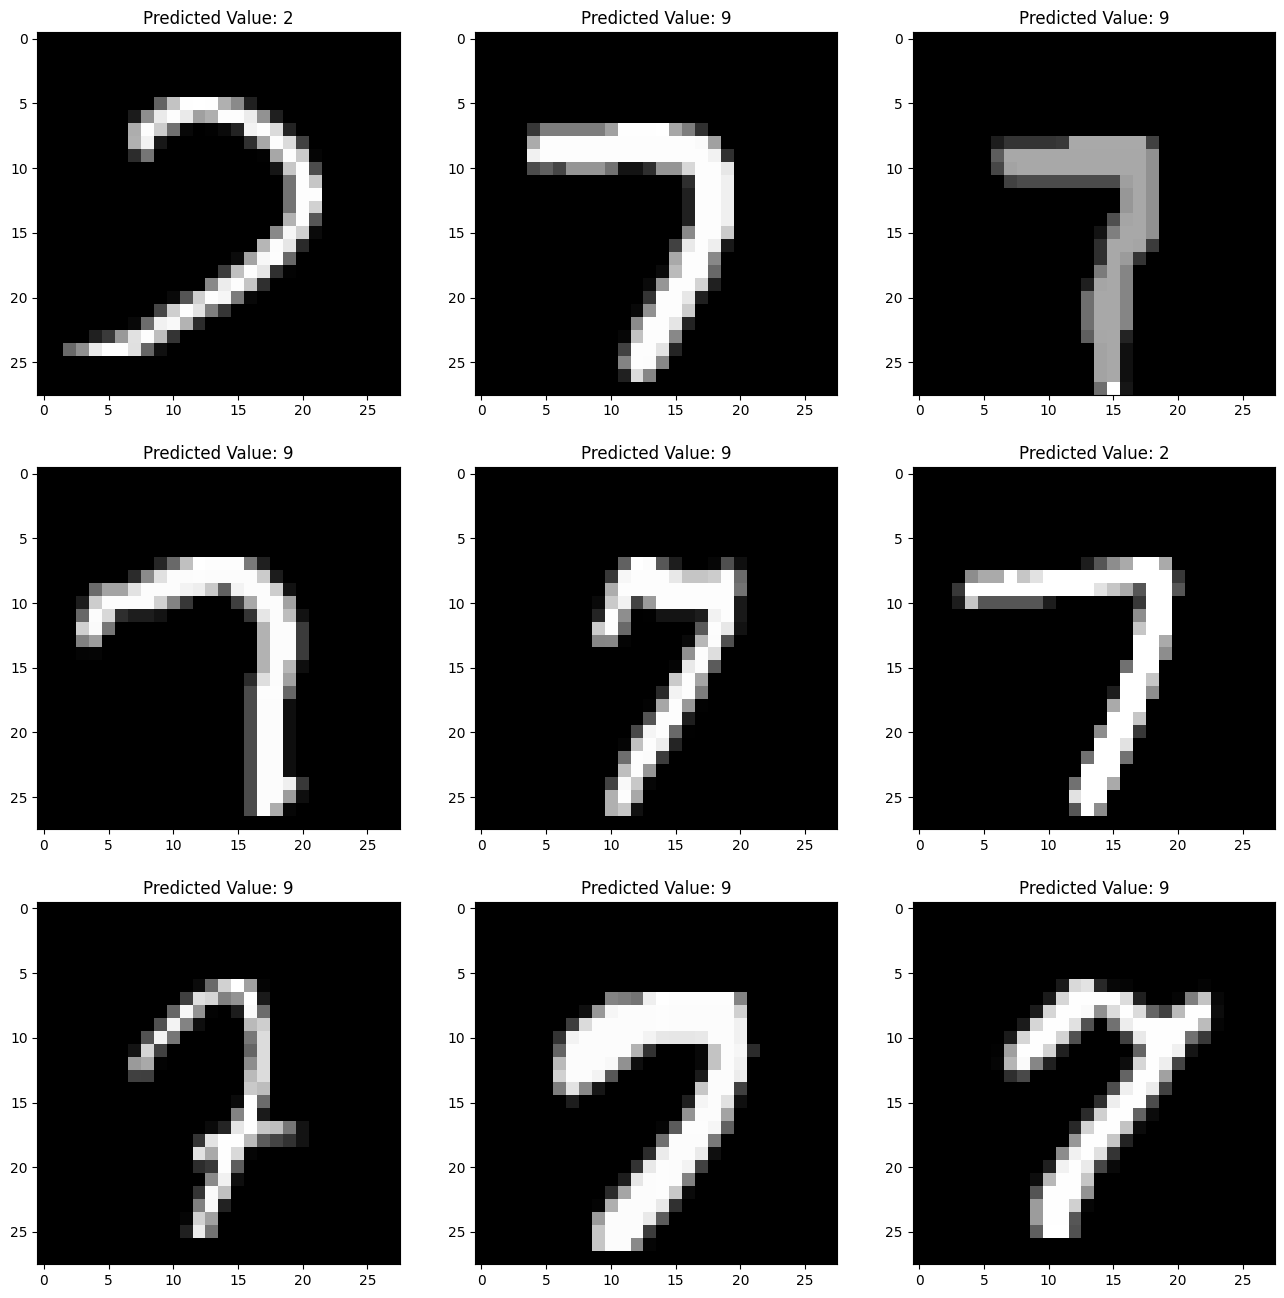

In [70]:
# Nine random 7s with the model's predictions. Expect mostly 1, 9 and 2 -
# the digits whose strokes overlap most with a 7.
fig,ax = plt.subplots( 3,3, figsize=(16,16))
ax = ax.flatten()

for i in range(9):
  randPic = np.random.randint(0,len(test_data))

  img = test_data[randPic].cpu().reshape(28,28)

  ax[i].imshow(img,cmap='grey')
  ax[i].set_title(f'Predicted Value: {(torch.argmax(preds[randPic])).item()}')

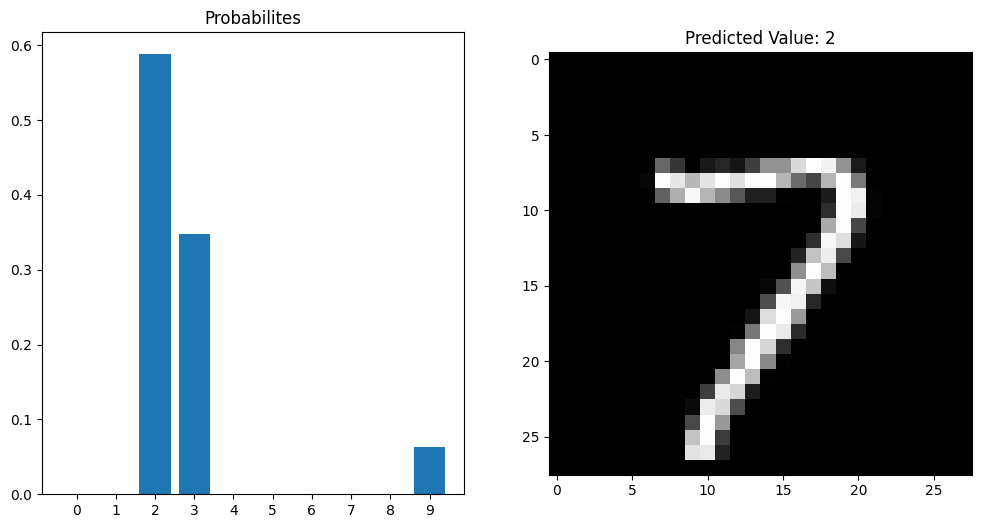

In [115]:
# The interesting plot: the probability distribution for a single 7.
# It is usually peaked, not flat - the model is confidently wrong.
# Bar 7 stays near zero: an untrained logit is not a 'reject' option.
# Detecting inputs like this needs a different mechanism (an explicit reject
# class, an entropy threshold, or an out-of-distribution detector).
# Diving deep into one result

randPic = np.random.randint(0,len(test_data))
fig,ax = plt.subplots(1,2,figsize = (12,6))

img = test_data[randPic].cpu().reshape(28,28)
predImg = preds[randPic]

ax[0].bar(range(10),torch.softmax(predImg,dim=0).cpu().detach());
ax[0].set_title("Probabilites")
ax[0].set_xticks(range(10))

ax[1].imshow(img,cmap='grey');
ax[1].set_title(f"Predicted Value: {(torch.argmax(preds[randPic])).item()}");